### Name = Aftab ALI
### Roll No = 042
### Section = BSDS-4A

## 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("\nFirst few rows of training data:")
print(train_df.head())

Train set shape: (8693, 14)
Test set shape: (4277, 13)

First few rows of training data:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported 

In [2]:
# Numerical features analysis
print("\n" + "="*70)
print("NUMERICAL FEATURES ANALYSIS")
print("="*70)
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
print(train_df[numerical_cols].describe())

# Spending pattern analysis
train_df['TotalSpending'] = train_df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
print(f"\nTotal Spending Statistics:")
print(f"Mean: {train_df['TotalSpending'].mean():.2f}")
print(f"Median: {train_df['TotalSpending'].median():.2f}")
print(f"Max: {train_df['TotalSpending'].max():.2f}")

# Categorical features analysis
print("\n" + "="*70)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*70)
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(train_df[col].value_counts())


NUMERICAL FEATURES ANALYSIS
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  

Total Spending Statistics:
Mean: 1440.87
Median: 716.00
Max: 35987.00


TARGET VARIABLE DISTRIBUTION
False (Not Transported): 4315 (49.64%)
True (Transported):      4378 (50.36%)


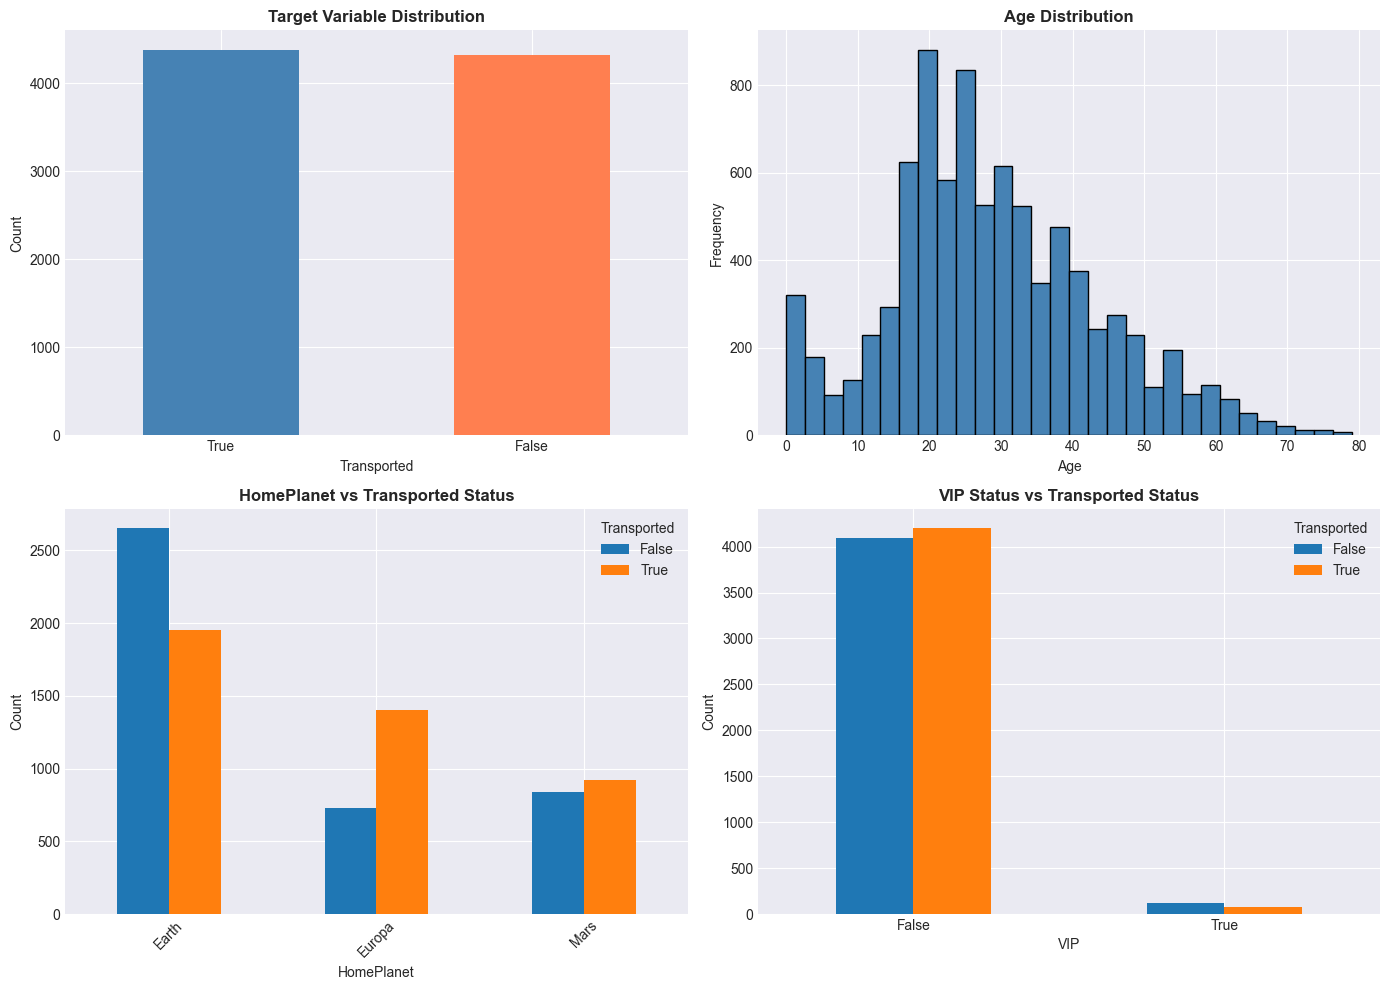


Visualizations created successfully!


In [3]:
# Target variable distribution
print("\n" + "="*70)
print("TARGET VARIABLE DISTRIBUTION")
print("="*70)
target_counts = train_df['Transported'].value_counts()
target_pcts = train_df['Transported'].value_counts(normalize=True) * 100
print(f"False (Not Transported): {target_counts[False]} ({target_pcts[False]:.2f}%)")
print(f"True (Transported):      {target_counts[True]} ({target_pcts[True]:.2f}%)")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target distribution
train_df['Transported'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'])
axes[0, 0].set_title('Target Variable Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Transported')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Age distribution
train_df['Age'].dropna().hist(bins=30, ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# 3. HomePlanet vs Transported
pd.crosstab(train_df['HomePlanet'], train_df['Transported']).plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('HomePlanet vs Transported Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('HomePlanet')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Transported', labels=['False', 'True'])
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. VIP vs Transported
pd.crosstab(train_df['VIP'], train_df['Transported']).plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('VIP Status vs Transported Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('VIP')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Transported', labels=['False', 'True'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\nVisualizations created successfully!")

In [4]:
# Data info and missing values
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print("\nData Types:")
print(train_df.dtypes)

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)
missing_train = train_df.isnull().sum()
missing_pct = (missing_train / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_train.index,
    'Missing_Count': missing_train.values,
    'Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(train_df.describe())

DATASET INFORMATION

Data Types:
PassengerId       object
HomePlanet        object
CryoSleep         object
Cabin             object
Destination       object
Age              float64
VIP               object
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Name              object
Transported         bool
TotalSpending    float64
dtype: object

MISSING VALUES ANALYSIS
          Column  Missing_Count  Percentage
2      CryoSleep            217    2.496261
9   ShoppingMall            208    2.392730
6            VIP            203    2.335212
1     HomePlanet            201    2.312205
12          Name            200    2.300702
3          Cabin            199    2.289198
11        VRDeck            188    2.162660
10           Spa            183    2.105142
8      FoodCourt            183    2.105142
4    Destination            182    2.093639
7    RoomService            181    2.082135
5            Age         

## 2. Data Preprocessing

In [9]:
def preprocess_data(df, is_train=True, label_encoders=None):
    """
    Comprehensive preprocessing pipeline for train and test data
    """
    df = df.copy()
    
    # 1. Extract features from Cabin (Deck, Num, Side)
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = pd.to_numeric(df['Num'], errors='coerce')
    
    # 2. Extract group information from PassengerId
    df['GroupId'] = df['PassengerId'].str.extract(r'(\d+)_')[0].astype(int)
    
    # 3. Fill missing numerical values with median
    numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num']
    for col in numerical_features:
        if col in df.columns:
            df[col].fillna(df[col].median(), inplace=True)
    
    # 4. Fill missing categorical values
    df['CryoSleep'].fillna(False, inplace=True)
    df['VIP'].fillna(False, inplace=True)
    df['HomePlanet'].fillna(df['HomePlanet'].mode()[0] if is_train else 'Earth', inplace=True)
    df['Destination'].fillna(df['Destination'].mode()[0] if is_train else 'TRAPPIST-1e', inplace=True)
    df['Deck'].fillna('Unknown', inplace=True)
    df['Side'].fillna('Unknown', inplace=True)
    
    # 5. Create engineered features
    df['TotalSpending'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['SpendingCategories'] = (df[spending_cols] > 0).sum(axis=1)
    df['AvgSpending'] = df['TotalSpending'] / (df['SpendingCategories'] + 1)
    
    # Age groups
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                            labels=['Child', 'Teen', 'Adult', 'Senior', 'Elderly'])
    
    # Spending level
    df['SpendingLevel'] = pd.cut(df['TotalSpending'], bins=[-1, 0, 1000, 5000, float('inf')], 
                                 labels=['None', 'Low', 'Medium', 'High'])
    
    # 6. Encode categorical variables
    categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'AgeGroup', 'SpendingLevel']
    
    new_encoders = {}
    for col in categorical_features:
        if col in df.columns:
            if is_train:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                new_encoders[col] = le
            else:
                df[col] = label_encoders[col].transform(df[col].astype(str))
    
    # 7. Select features for modeling
    feature_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 
                    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                    'Num', 'Deck', 'Side', 'TotalSpending', 'AvgSpending', 
                    'AgeGroup', 'SpendingLevel', 'SpendingCategories']
    
    X = df[feature_cols].copy()
    
    if is_train:
        y = df['Transported'].astype(int)
        return X, y, new_encoders
    else:
        return X

# Preprocess training data
X_train, y_train, encoders = preprocess_data(train_df, is_train=True)

print("Training data preprocessing complete!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nFeatures: {list(X_train.columns)}")
print(f"\nX_train statistics:")
print(X_train.describe())

# Feature scaling and train-validation split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Split into train and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, 
                                             test_size=0.2, random_state=42, stratify=y_train)

print("\nTrain-Validation Split Summary:")
print(f"Train set size: {X_tr.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"\nClass distribution in training set:")
print(y_tr.value_counts(normalize=True))
print(f"\nClass distribution in validation set:")
print(y_val.value_counts(normalize=True))

Training data preprocessing complete!
X_train shape: (8693, 18)
y_train shape: (8693,)

Features: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num', 'Deck', 'Side', 'TotalSpending', 'AvgSpending', 'AgeGroup', 'SpendingLevel', 'SpendingCategories']

X_train statistics:
        HomePlanet    CryoSleep  Destination          Age          VIP  \
count  8693.000000  8693.000000  8693.000000  8693.000000  8693.000000   
mean      0.649833     0.349362     1.494306    28.790291     0.022892   
std       0.795183     0.476796     0.814966    14.341404     0.149568   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     1.000000    20.000000     0.000000   
50%       0.000000     0.000000     2.000000    27.000000     0.000000   
75%       1.000000     1.000000     2.000000    37.000000     0.000000   
max       2.000000     1.000000     2.000000    79.000000     1.0

## 3. Model Training and Comparison

In [10]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    """
    Evaluate model performance with multiple metrics
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Probabilities for ROC
    y_val_proba = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    val_auc = roc_auc_score(y_val, y_val_proba)
    
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Train Accuracy:  {train_acc:.4f}")
    print(f"Val Accuracy:    {val_acc:.4f}")
    print(f"Val Precision:   {val_precision:.4f}")
    print(f"Val Recall:      {val_recall:.4f}")
    print(f"Val F1-Score:    {val_f1:.4f}")
    print(f"Val ROC-AUC:     {val_auc:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    print(f"\nConfusion Matrix:")
    print(f"True Negatives:  {cm[0, 0]}")
    print(f"False Positives: {cm[0, 1]}")
    print(f"False Negatives: {cm[1, 0]}")
    print(f"True Positives:  {cm[1, 1]}")
    
    return {
        'Model': model_name,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Precision': val_precision,
        'Recall': val_recall,
        'F1': val_f1,
        'ROC_AUC': val_auc,
        'Model_Object': model
    }

# Model 1: Logistic Regression - Baseline
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_tr, y_tr)
lr_results = evaluate_model(lr_model, X_tr, X_val, y_tr, y_val, "Logistic Regression")

# Model 2: Random Forest
print("\n\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42, n_jobs=-1, verbose=0)
rf_model.fit(X_tr, y_tr)
rf_results = evaluate_model(rf_model, X_tr, X_val, y_tr, y_val, "Random Forest")

# Model 3: Gradient Boosting
print("\n\nTraining Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, 
                                      learning_rate=0.1, random_state=42)
gb_model.fit(X_tr, y_tr)
gb_results = evaluate_model(gb_model, X_tr, X_val, y_tr, y_val, "Gradient Boosting")

Training Logistic Regression...

Logistic Regression
Train Accuracy:  0.7919
Val Accuracy:    0.7872
Val Precision:   0.7817
Val Recall:      0.8014
Val F1-Score:    0.7914
Val ROC-AUC:     0.8756

Confusion Matrix:
True Negatives:  667
False Positives: 196
False Negatives: 174
True Positives:  702


Training Random Forest...

Random Forest
Train Accuracy:  0.9340
Val Accuracy:    0.8097
Val Precision:   0.8240
Val Recall:      0.7911
Val F1-Score:    0.8072
Val ROC-AUC:     0.9024

Confusion Matrix:
True Negatives:  715
False Positives: 148
False Negatives: 183
True Positives:  693


Training Gradient Boosting...

Gradient Boosting
Train Accuracy:  0.8769
Val Accuracy:    0.8154
Val Precision:   0.8143
Val Recall:      0.8208
Val F1-Score:    0.8175
Val ROC-AUC:     0.9105

Confusion Matrix:
True Negatives:  699
False Positives: 164
False Negatives: 157
True Positives:  719




MODEL COMPARISON
              Model  Train_Acc  Val_Acc  Precision   Recall       F1  ROC_AUC
Logistic Regression   0.791918 0.787234   0.781737 0.801370 0.791432 0.875587
      Random Forest   0.933995 0.809661   0.824019 0.791096 0.807222 0.902399
  Gradient Boosting   0.876905 0.815411   0.814270 0.820776 0.817510 0.910517


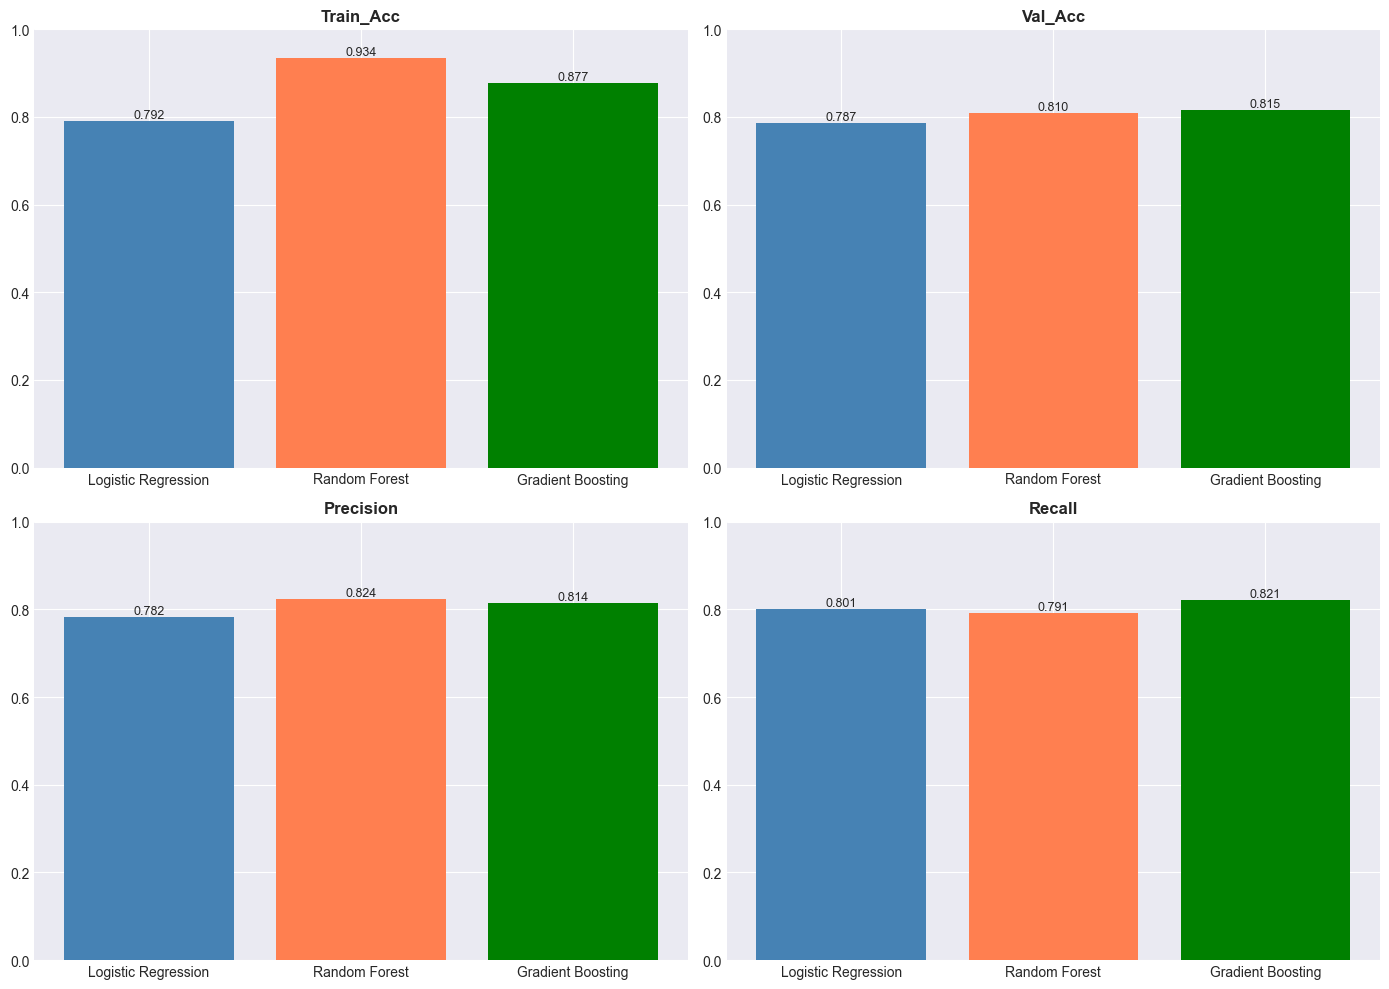


Model comparison visualization created!


In [11]:
# Model comparison
print("\n\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
results_df = pd.DataFrame([
    {k: v for k, v in lr_results.items() if k != 'Model_Object'},
    {k: v for k, v in rf_results.items() if k != 'Model_Object'},
    {k: v for k, v in gb_results.items() if k != 'Model_Object'}
])
print(results_df.to_string(index=False))

# Model comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['Train_Acc', 'Val_Acc', 'Precision', 'Recall']
results_vis = results_df.copy()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = results_vis[metric].values
    colors = ['steelblue', 'coral', 'green']
    bars = ax.bar(results_vis['Model'], values, color=colors)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nModel comparison visualization created!")

## 4. Hyperparameter Tuning & Model Improvement

In [12]:
# Hyperparameter tuning for Gradient Boosting (best performing model)
print("Performing hyperparameter tuning for Gradient Boosting...")
print("="*60)

# Simplified parameter grid for faster execution
param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.08, 0.12],
    'max_depth': [4, 5],
    'min_samples_leaf': [2, 3]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print(f"Searching {len(param_grid['n_estimators']) * len(param_grid['learning_rate']) * len(param_grid['max_depth']) * len(param_grid['min_samples_leaf'])} parameter combinations with 3-fold CV...")
gb_grid.fit(X_tr, y_tr)
print("GridSearch completed!")

print(f"Best parameters found:")
for param, value in gb_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation ROC-AUC: {gb_grid.best_score_:.4f}")

# Evaluate tuned model
tuned_gb_model = gb_grid.best_estimator_
tuned_gb_results = evaluate_model(tuned_gb_model, X_tr, X_val, y_tr, y_val, "Tuned Gradient Boosting")

Performing hyperparameter tuning for Gradient Boosting...
Searching 16 parameter combinations with 3-fold CV...
GridSearch completed!
Best parameters found:
  learning_rate: 0.08
  max_depth: 4
  min_samples_leaf: 3
  n_estimators: 150

Best cross-validation ROC-AUC: 0.8937

Tuned Gradient Boosting
Train Accuracy:  0.8503
Val Accuracy:    0.8079
Val Precision:   0.8025
Val Recall:      0.8208
Val F1-Score:    0.8115
Val ROC-AUC:     0.9087

Confusion Matrix:
True Negatives:  686
False Positives: 177
False Negatives: 157
True Positives:  719




FEATURE IMPORTANCE ANALYSIS

Top 10 Important Features:
          Feature  Importance
16  SpendingLevel    0.203121
13  TotalSpending    0.109383
6       FoodCourt    0.092700
8             Spa    0.072080
14    AvgSpending    0.065243
9          VRDeck    0.064213
7    ShoppingMall    0.063155
10            Num    0.062696
1       CryoSleep    0.054409
0      HomePlanet    0.052450


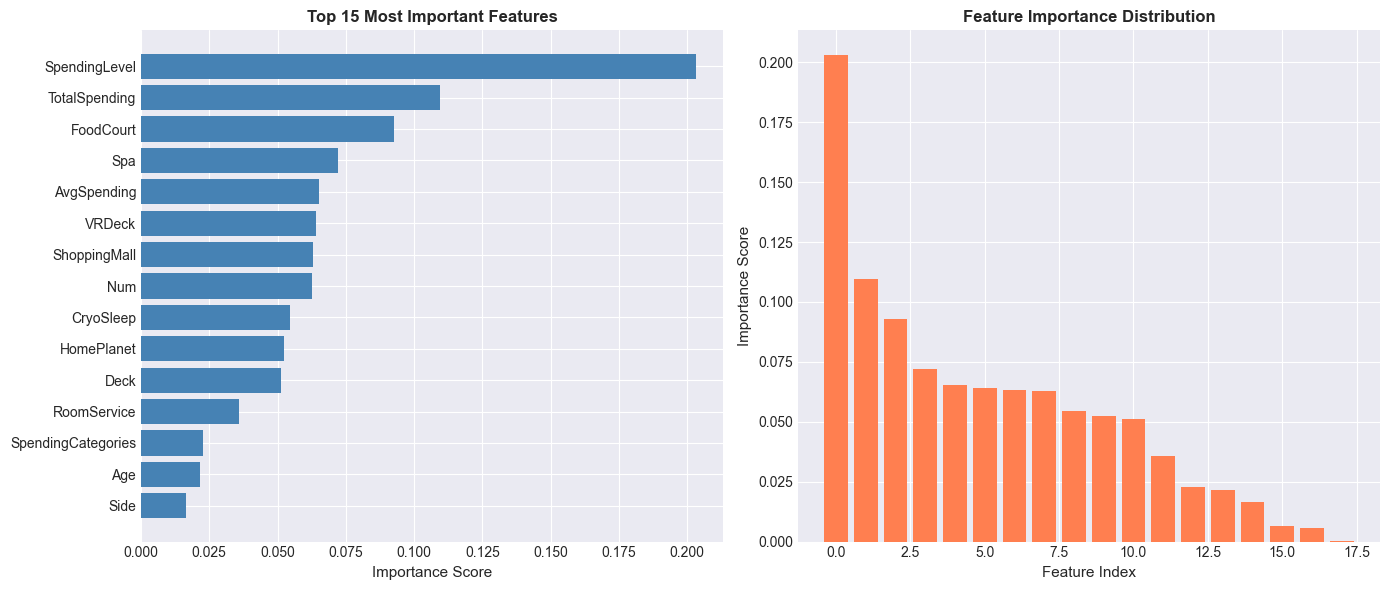


Feature importance visualization created!


In [13]:
# Feature importance analysis
print("\n\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tuned_gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 features
top_features = feature_importance.head(15)
axes[0].barh(top_features['Feature'], top_features['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Top 15 Most Important Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# All features in order
axes[1].bar(range(len(feature_importance)), feature_importance['Importance'].values, color='coral')
axes[1].set_xlabel('Feature Index', fontsize=11)
axes[1].set_ylabel('Importance Score', fontsize=11)
axes[1].set_title('Feature Importance Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFeature importance visualization created!")

## 5. Final Model Training & Test Predictions

In [16]:
# Train final model on full training data
print("Training final model on complete training data...")
print("="*60)

final_model = GradientBoostingClassifier(
    n_estimators=gb_grid.best_params_['n_estimators'],
    learning_rate=gb_grid.best_params_['learning_rate'],
    max_depth=gb_grid.best_params_['max_depth'],
    min_samples_leaf=gb_grid.best_params_['min_samples_leaf'],
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

# Evaluate on full training data
y_train_pred_final = final_model.predict(X_train_scaled)
y_train_proba_final = final_model.predict_proba(X_train_scaled)[:, 1]
train_acc_final = accuracy_score(y_train, y_train_pred_final)
train_f1_final = f1_score(y_train, y_train_pred_final)
train_auc_final = roc_auc_score(y_train, y_train_proba_final)

print(f"\nFinal Model Performance on Full Training Data:")
print(f"Accuracy: {train_acc_final:.4f}")
print(f"F1-Score: {train_f1_final:.4f}")
print(f"ROC-AUC:  {train_auc_final:.4f}")

# Cross-validation evaluation
cv_scores_auc = cross_val_score(final_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
cv_scores_acc = cross_val_score(final_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Results:")
print(f"ROC-AUC Scores: {cv_scores_auc}")
print(f"Mean CV ROC-AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std():.4f})")
print(f"Mean CV Accuracy: {cv_scores_acc.mean():.4f} (+/- {cv_scores_acc.std():.4f})")

Training final model on complete training data...

Final Model Performance on Full Training Data:
Accuracy: 0.8508
F1-Score: 0.8542
ROC-AUC:  0.9385

5-Fold Cross-Validation Results:
ROC-AUC Scores: [0.8534408  0.86735702 0.89295399 0.91151266 0.88533289]
Mean CV ROC-AUC: 0.8821 (+/- 0.0202)
Mean CV Accuracy: 0.7799 (+/- 0.0230)


In [17]:
# Preprocess test data
X_test = preprocess_data(test_df, is_train=False, label_encoders=encoders)

# Scale test data using the same scaler
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Make predictions
test_predictions = final_model.predict(X_test_scaled)
test_probabilities = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"Test Set Predictions Summary:")
print(f"Total predictions: {len(test_predictions)}")
print(f"Not Transported (False): {(test_predictions == 0).sum()}")
print(f"Transported (True): {(test_predictions == 1).sum()}")
print(f"\nPrediction confidence statistics:")
print(f"Min probability: {test_probabilities.min():.4f}")
print(f"Max probability: {test_probabilities.max():.4f}")
print(f"Mean probability: {test_probabilities.mean():.4f}")

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_predictions.astype(bool)
})

print(f"\nFirst 10 predictions:")
print(submission.head(10))

# Save submission
submission.to_csv('sample_submission.csv', index=False)
print(f"\n✓ Submission saved to 'sample_submission.csv'")
print(f"Submission shape: {submission.shape}")

Test Set Predictions Summary:
Total predictions: 4277
Not Transported (False): 2059
Transported (True): 2218

Prediction confidence statistics:
Min probability: 0.0037
Max probability: 0.9932
Mean probability: 0.5046

First 10 predictions:
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01         True
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True

✓ Submission saved to 'sample_submission.csv'
Submission shape: (4277, 2)
